# WMATA vehicle motion + dwell — 2026-05-20

Thin demo of `analysis.VehicleDay`. The module owns parquet I/O, dwell
detection, and per-stop aggregation; the notebook just calls the API and
plots.

In [1]:
import datetime as dt
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from analysis import VehicleDay

day = VehicleDay("wmata-vehicles", dt.date(2026, 5, 20), base_dir=PROJECT_ROOT / "curated")
day

VehicleDay(feed='wmata-vehicles', date=2026-05-20)

## Day overview

In [2]:
print(f"vehicles : {day.vehicle_count}")
print(f"pings    : {day.ping_count:,}")
print(f"stops    : {len(day.stops)}")

total_dwells = sum(len(v.dwells) for v in day.vehicles)
print(f"dwells   : {total_dwells:,}")

vehicles : 401
pings    : 337,127
stops    : 125
dwells   : 41,229


## A single vehicle's day

Vehicle pings come in every ~15s. A *dwell* is a run of consecutive
`STOPPED_AT` pings at the same `stop_id`.

In [3]:
busiest_vehicle = max(day.vehicles, key=lambda v: v.ping_count)
print(busiest_vehicle)
print(f"  trips run today: {len(busiest_vehicle.trip_ids)}")
print(f"  dwells: {len(busiest_vehicle.dwells)}")

visits = busiest_vehicle.dwells
pd.DataFrame([{
    "stop_id": v.stop_id,
    "route": v.route_id,
    "arrival": dt.datetime.fromtimestamp(v.arrival_ts, tz=dt.timezone.utc),
    "dwell_s": v.duration_s,
    "pings": v.ping_count,
} for v in visits[:10]])

Vehicle('406', pings=3308)
  trips run today: 26
  dwells: 391


,stop_id,route,arrival,dwell_s,pings
0,PF_C13_C,BLUE,2026-05-20 00:03:58+00:00,61,4
1,PF_C12_C,BLUE,2026-05-20 00:06:05+00:00,46,3
2,PF_C11_1,BLUE,2026-05-20 00:08:43+00:00,40,3
3,PF_C10_1,BLUE,2026-05-20 00:12:24+00:00,90,5
4,PF_C09_1,BLUE,2026-05-20 00:15:03+00:00,21,2
5,PF_C08_1,BLUE,2026-05-20 00:17:22+00:00,70,4
6,PF_C07_1,BLUE,2026-05-20 00:19:59+00:00,48,3
7,PF_C06_1,BLUE,2026-05-20 00:22:38+00:00,47,3
8,PF_C05_1,BLUE,2026-05-20 00:24:35+00:00,47,3
9,PF_C04_C,BLUE,2026-05-20 00:27:13+00:00,22,2


### Dwell timeline for that vehicle

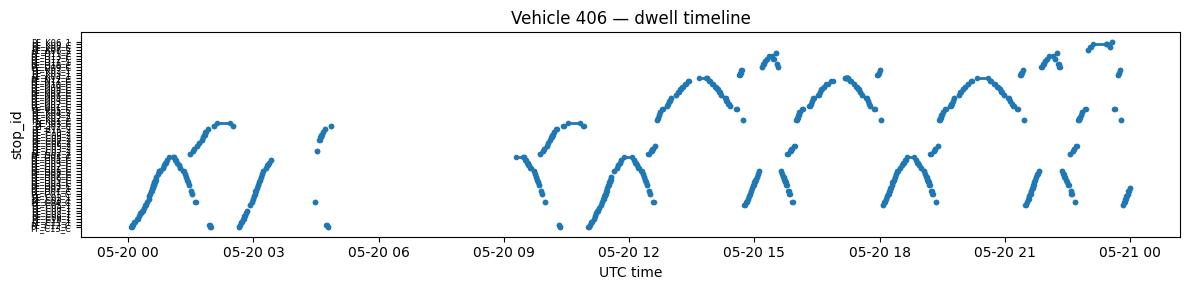

In [4]:
fig, ax = plt.subplots(figsize=(12, 3))
for v in busiest_vehicle.dwells:
    arr = dt.datetime.fromtimestamp(v.arrival_ts, tz=dt.timezone.utc)
    dep = dt.datetime.fromtimestamp(v.departure_ts, tz=dt.timezone.utc)
    ax.plot([arr, dep], [v.stop_id, v.stop_id], "o-", color="C0", markersize=3, linewidth=2)
ax.set_xlabel("UTC time")
ax.set_ylabel("stop_id")
ax.set_title(f"Vehicle {busiest_vehicle.vehicle_id} — dwell timeline")
ax.tick_params(axis="y", labelsize=6)
plt.tight_layout()
plt.show()

## Dwell duration distribution (all vehicles)

How long do trains actually sit at platforms?

count    41229.000000
mean        51.282980
std        185.787465
min          0.000000
50%         41.000000
75%         46.000000
90%         66.000000
99%        539.720000
max      24777.000000
dtype: float64


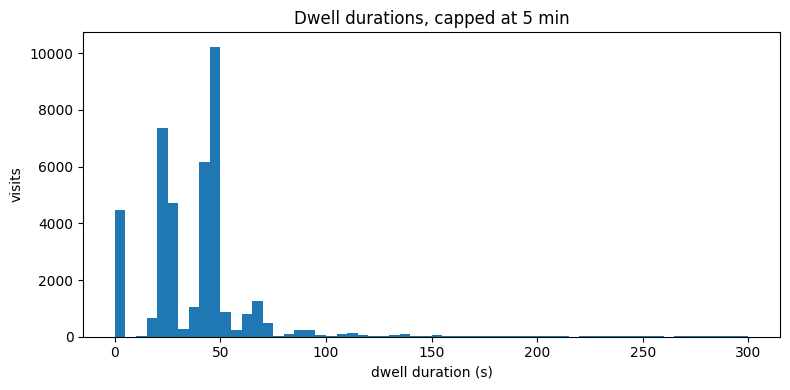

In [5]:
all_dwells = [v.duration_s for veh in day.vehicles for v in veh.dwells]
s = pd.Series(all_dwells)
print(s.describe(percentiles=[.5, .75, .9, .99]))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist([d for d in all_dwells if d <= 300], bins=60)
ax.set_xlabel("dwell duration (s)")
ax.set_ylabel("visits")
ax.set_title("Dwell durations, capped at 5 min")
plt.tight_layout()
plt.show()

## Headways at the busiest stop, split by route

Mixing routes at a transfer station hides the actual service interval per
line. Per-route headway is what riders experience.

In [6]:
busiest_stop = max(day.stops, key=lambda s: s.visit_count)
print(busiest_stop)
print(f"  routes served: {busiest_stop.routes_served}")

rows = []
for route in sorted(busiest_stop.routes_served):
    hw = busiest_stop.headways(route_id=route)
    hw_clean = [h for h in hw if 30 <= h <= 3600]
    if not hw_clean:
        continue
    s = pd.Series(hw_clean)
    rows.append({
        "route": route,
        "n": len(hw_clean),
        "p50_s": int(s.median()),
        "p90_s": int(s.quantile(0.9)),
        "min_s": int(s.min()),
        "max_s": int(s.max()),
    })
pd.DataFrame(rows)

Stop('PF_F01_C', visits=747)
  routes served: {'YELLOW', 'GREEN'}


,route,n,p50_s,p90_s,min_s,max_s
0,GREEN,332,200,343,35,1156
1,YELLOW,326,204,353,36,667


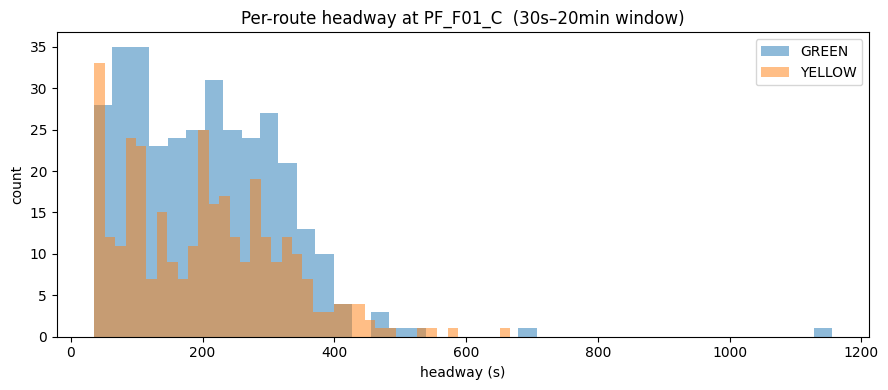

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
for route in sorted(busiest_stop.routes_served):
    hw = [h for h in busiest_stop.headways(route_id=route) if 30 <= h <= 1200]
    if hw:
        ax.hist(hw, bins=40, alpha=0.5, label=route)
ax.set_xlabel("headway (s)")
ax.set_ylabel("count")
ax.set_title(f"Per-route headway at {busiest_stop.stop_id}  (30s–20min window)")
ax.legend()
plt.tight_layout()
plt.show()